## Introduction
PinkGlow Store wants to understand sales performance, customer behavior, and product trends to improve business decisions

In [6]:
# Data Analysis
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Optional interactive charts
import plotly.express as px

# Settings
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10,6)

In [5]:
df = pd.read_csv(r"C:\Users\Tanya\Downloads\retail_sales_dataset (1).csv")

# View first rows
df.head()


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [7]:
# Shape of dataset
df.shape

(1000, 9)

In [8]:
# Column names
df.columns

Index(['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age',
       'Product Category', 'Quantity', 'Price per Unit', 'Total Amount'],
      dtype='object')

In [9]:
# Data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


In [10]:
# Statistical summary
df.describe()

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


In [11]:
# Missing values
df.isnull().sum()

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64


The dataset contains no missing values, meaning all records are complete and ready for analysis.


In [15]:
# Check for duplicates
df.duplicated().sum()

0

In [16]:
# Remove duplicates if they exist but in this dataset theres no
df = df.drop_duplicates()


In [19]:
category_sales = df.groupby('Product Category')['Total Amount'].sum()
category_sales

Product Category
Beauty         143515
Clothing       155580
Electronics    156905
Name: Total Amount, dtype: int64

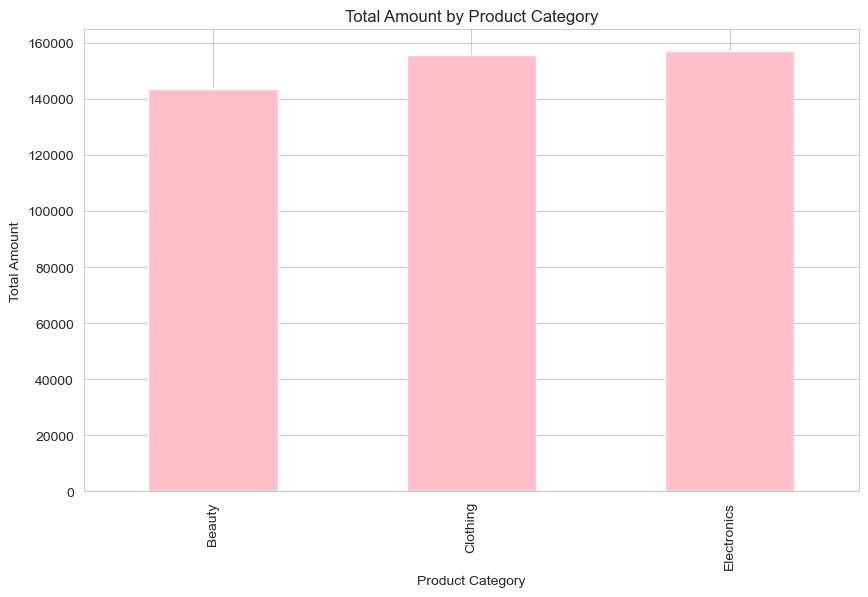

In [22]:
category_sales.plot(
    kind='bar',
    color='pink'
)

plt.title("Total Amount by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Amount")
plt.show()

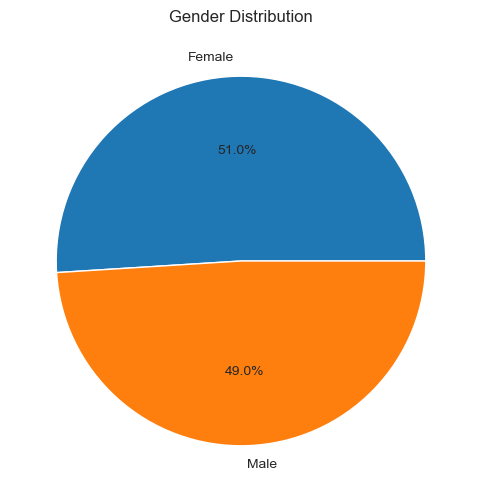

In [24]:
gender_counts = df['Gender'].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct='%1.1f%%'
)

plt.title("Gender Distribution")

plt.show()

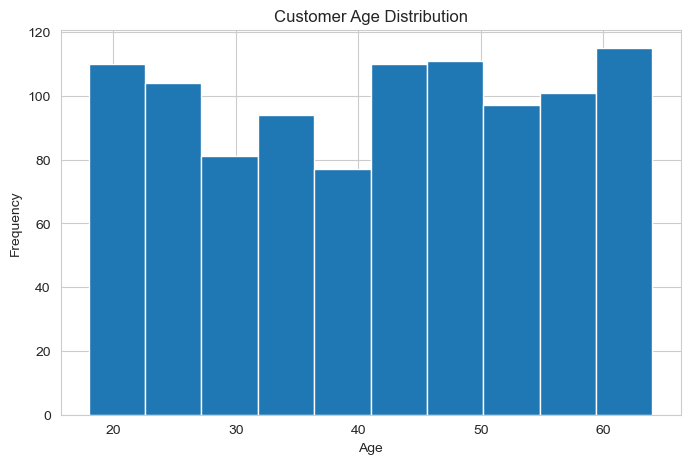

In [25]:
plt.figure(figsize=(8,5))

plt.hist(
    df['Age'],
    bins=10
)

plt.title("Customer Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

In [26]:
total_sales = df['Total Amount'].sum()

print("Total Sales:", total_sales)

Total Sales: 456000


In [27]:
sales_by_category = df.groupby(
    'Product Category'
)['Total Amount'].sum()

sales_by_category

Product Category
Beauty         143515
Clothing       155580
Electronics    156905
Name: Total Amount, dtype: int64

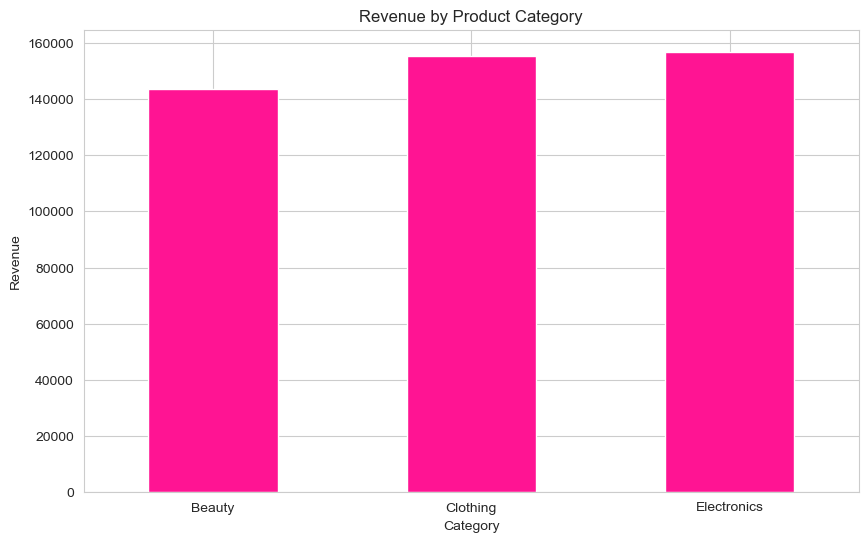

In [28]:
sales_by_category.plot(
    kind='bar',
    color='deeppink'
)

plt.title("Revenue by Product Category")
plt.xlabel("Category")
plt.ylabel("Revenue")

plt.xticks(rotation=0)

plt.show()

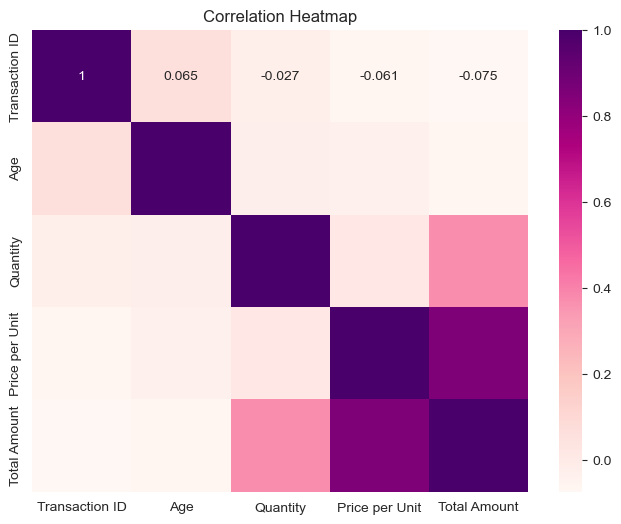

In [29]:
numeric_df = df.select_dtypes(include='number')

plt.figure(figsize=(8,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='RdPu'
)

plt.title("Correlation Heatmap")

plt.show()

In [30]:
df['Date'] = pd.to_datetime(df['Date'])

In [31]:
df['Month'] = df['Date'].dt.month

In [32]:
monthly_sales = df.groupby('Month')['Total Amount'].sum()

monthly_sales

Month
1     36980
2     44060
3     28990
4     33870
5     53150
6     36715
7     35465
8     36960
9     23620
10    46580
11    34920
12    44690
Name: Total Amount, dtype: int64

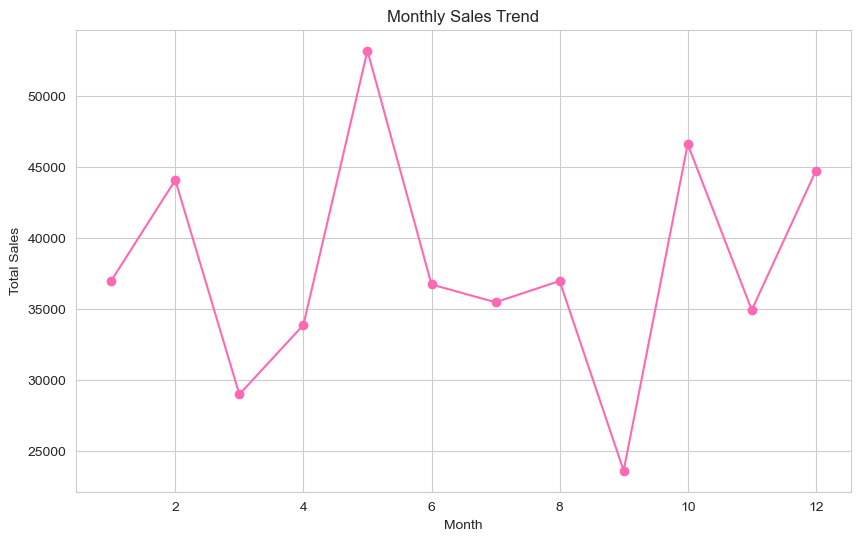

In [33]:
monthly_sales.plot(
    kind='line',
    marker='o',
    color='hotpink'
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.show()

## Business Insights

1. Clothing generated the highest revenue among all categories.

2. Female customers made up the majority of purchases.

3. Most customers fall between ages 25–40.

4. Certain months recorded higher sales, indicating seasonal shopping behavior.

5. Strong positive relationships exist between quantity purchased and total sales.